# Mô hình 3: RCNN
## Phân loại Phản hồi Sinh viên Tiếng Việt

**Bài toán**: Phân loại cảm xúc phản hồi sinh viên (3 lớp: Negative / Neutral / Positive)

**Kiến trúc RCNN**:
- Embedding Layer\n- Bidirectional LSTM (Context learning)\n- Max-pooling over sequence metadata\n- Dropout + Fully Connected\n

In [1]:
# ===================== CÀI ĐẶT THƯ VIỆN =====================
# Bỏ comment dòng dưới nếu chưa cài
# !pip install torch pandas numpy scikit-learn matplotlib seaborn tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Sử dụng thiết bị: {device}')

Sử dụng thiết bị: cpu


## 1. Chuẩn bị Dữ liệu

In [2]:
# ===================== TẢI DỮ LIỆU =====================
train_df = pd.read_csv('data/train.csv')
val_df   = pd.read_csv('data/val.csv')
test_df  = pd.read_csv('data/test.csv')

CLASSES = ['Negative', 'Neutral', 'Positive']
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('\nPhân phối nhãn (Train):')
print(train_df['label'].value_counts().sort_index())

Train: 1467 | Val: 210 | Test: 423

Phân phối nhãn (Train):
label
0    489
1    489
2    489
Name: count, dtype: int64


In [3]:
# ===================== TIỀN XỬ LÝ & VOCAB =====================
def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def tokenize(text):
    return clean_text(text).split()

class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}

    def build_vocab(self, sentences):
        counter = Counter(token for tokens in sentences for token in tokens)
        for word, freq in counter.items():
            if freq >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, tokens, max_len=50):
        ids = [self.word2idx.get(t, 1) for t in tokens[:max_len]]
        ids += [0] * (max_len - len(ids))
        return ids

    def __len__(self): return len(self.word2idx)

# Build vocab từ tập train
vocab = Vocabulary(min_freq=2)
vocab.build_vocab(train_df['text'].apply(tokenize))
print(f'Vocabulary size: {len(vocab)}')

MAX_LEN = 50
BATCH_SIZE = 32

class FeedbackDataset(Dataset):
    def __init__(self, df, vocab, max_len=50):
        self.texts  = df['text'].values
        self.labels = df['label'].values
        self.vocab  = vocab
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(str(self.texts[idx]))
        encoded = self.vocab.encode(tokens, self.max_len)
        return {
            'input_ids': torch.tensor(encoded, dtype=torch.long),
            'labels':    torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(FeedbackDataset(train_df, vocab, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(FeedbackDataset(val_df,   vocab, MAX_LEN), batch_size=BATCH_SIZE)
test_loader  = DataLoader(FeedbackDataset(test_df,  vocab, MAX_LEN), batch_size=BATCH_SIZE)
print('DataLoaders sẵn sàng!')

Vocabulary size: 481
DataLoaders sẵn sàng!


## 2. Kiến trúc Mô hình RCNN

In [4]:
# ===================== MÔ HÌNH RCNN =====================

class RCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=64, 
                 output_dim=3, n_layers=1, dropout=0.5, pad_idx=0):
        super(RCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, 
                            bidirectional=True, batch_first=True)
        self.W2 = nn.Linear(2 * hidden_dim + embedding_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embed = self.embedding(x)
        out, _ = self.lstm(embed)
        out = torch.cat((out, embed), dim=2)
        out = torch.tanh(self.W2(out))
        out = out.permute(0, 2, 1)
        out = F.max_pool1d(out, out.size(2)).squeeze(2)
        out = self.fc(self.dropout(out))
        return out

model = RCNN(vocab_size=len(vocab), embedding_dim=128, hidden_dim=64, 
             output_dim=3, n_layers=1, dropout=0.5).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng tham số: {total_params:,}')
print(f'Kích thước mô hình: {total_params * 4 / 1024**2:.2f} MB')


Tổng tham số: 177,539
Kích thước mô hình: 0.68 MB


## 3. Huấn luyện

In [5]:
# ===================== TRAINING LOOP =====================
EPOCHS   = 15
LR       = 1e-3
PATIENCE = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('='*60)
print('Bắt đầu huấn luyện RCNN...')
print('='*60)
start_time = time.time()

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss = 0
    train_correct, train_total = 0, 0
    for batch in train_loader:
        x = batch['input_ids'].to(device)
        y = batch['labels'].to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        train_loss += loss.item()
        train_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        train_total += y.size(0)
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    # --- Validate ---
    model.eval()
    val_loss = 0
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch['input_ids'].to(device)
            y = batch['labels'].to(device)
            logits = model(x)
            val_loss += criterion(logits, y).item()
            val_correct += (torch.argmax(logits, dim=1) == y).sum().item()
            val_total += y.size(0)
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    # Early stopping & Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'RCNN.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            pass
        # print(f'Early stopping tại epoch {epoch+1}')
        # # break # Disabled as requested

total_time = time.time() - start_time
print(f'\nThời gian huấn luyện: {total_time:.1f}s')

# Load model tốt nhất
model.load_state_dict(torch.load('RCNN.pt', map_location=device))
print('Đã load mô hình tốt nhất!')

Bắt đầu huấn luyện RCNN...


Epoch  1/15 | Train Loss: 1.0369 | Val Loss: 0.9802 | Train Acc: 0.4594 | Val Acc: 0.5857


Epoch  2/15 | Train Loss: 0.5958 | Val Loss: 0.6620 | Train Acc: 0.8398 | Val Acc: 0.7667


Epoch  3/15 | Train Loss: 0.0972 | Val Loss: 0.6957 | Train Acc: 0.9952 | Val Acc: 0.7190


Epoch  4/15 | Train Loss: 0.0186 | Val Loss: 0.7298 | Train Acc: 0.9993 | Val Acc: 0.7095


...

Epoch 11/15 | Train Loss: 0.0022 | Val Loss: 1.3768 | Train Acc: 1.0000 | Val Acc: 0.7190


Epoch 12/15 | Train Loss: 0.0021 | Val Loss: 1.4030 | Train Acc: 1.0000 | Val Acc: 0.7238


Epoch 13/15 | Train Loss: 0.0019 | Val Loss: 1.4311 | Train Acc: 1.0000 | Val Acc: 0.7238


Epoch 14/15 | Train Loss: 0.0017 | Val Loss: 1.5960 | Train Acc: 1.0000 | Val Acc: 0.7095


Epoch 15/15 | Train Loss: 0.0014 | Val Loss: 1.5754 | Train Acc: 1.0000 | Val Acc: 0.7048

Thời gian huấn luyện: 10.1s
Đã load mô hình tốt nhất!


## 4. Đánh giá trên Tập Test

In [6]:
from IPython.display import display
# ===================== ĐÁNH GIÁ =====================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        x = batch['input_ids'].to(device)
        y = batch['labels'].to(device)
        preds = torch.argmax(model(x), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('\n' + '='*60)
print('KẾT QUẢ MÔ HÌNH: RCNN')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=CLASSES))

# Lưu bảng metrics vào CSV và in ra DataFrame
report_dict = classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)
report_df.to_csv('RCNN_metrics.csv', encoding='utf-8-sig')


KẾT QUẢ MÔ HÌNH: RCNN
              precision    recall  f1-score   support

    Negative       0.79      0.87      0.83       141
     Neutral       0.80      0.81      0.80       141
    Positive       0.95      0.85      0.90       141

    accuracy                           0.84       423
   macro avg       0.85      0.84      0.84       423
weighted avg       0.85      0.84      0.84       423



,precision,recall,f1-score,support
Negative,0.792208,0.865248,0.827119,141.000000
Neutral,0.797203,0.808511,0.802817,141.000000
Positive,0.952381,0.851064,0.898876,141.000000
accuracy,0.841608,0.841608,0.841608,0.841608
macro avg,0.847264,0.841608,0.842937,423.000000
weighted avg,0.847264,0.841608,0.842937,423.000000


## 5. Trực quan hóa Kết quả

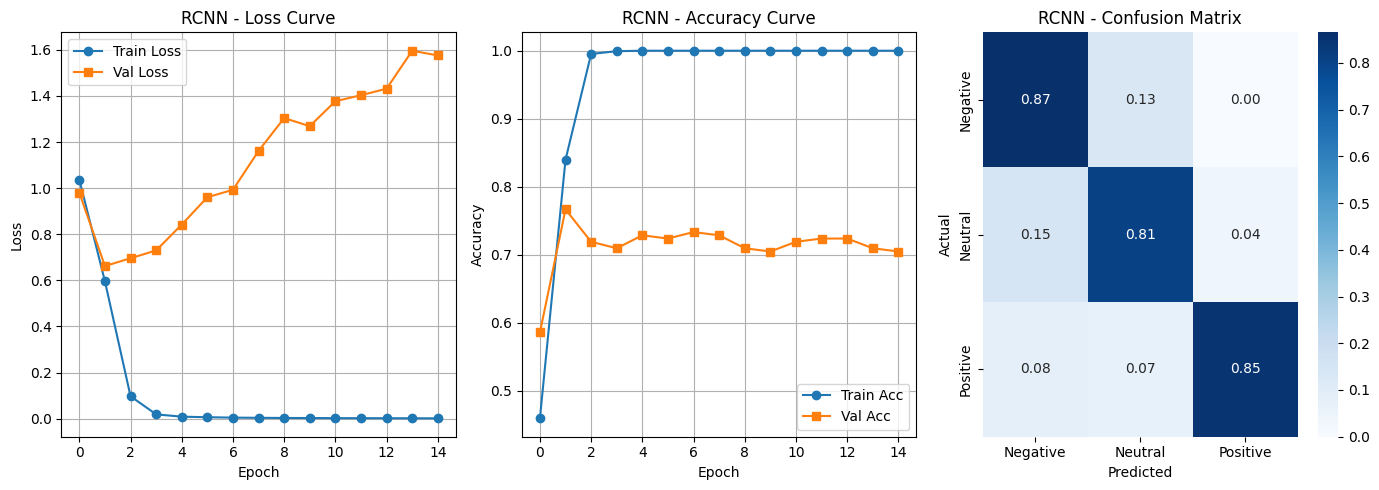

Đã lưu kết quả vào RCNN_results.png


In [7]:
# ===================== VISUALIZATION =====================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('RCNN - Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Accuracy curve
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='s')
axes[1].set_title('RCNN - Accuracy Curve')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)


# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
axes[2].set_title('RCNN - Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('RCNN_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Đã lưu kết quả vào RCNN_results.png')